In [1096]:
import mesa
import numpy as np
import pandas as pd
from collections import Counter, defaultdict

In [1097]:
try:
    demographic_distributions = pd.read_csv('demog_distrib.csv')

    region_cols = demographic_distributions[['region', 'total_pop']]
    gender_cols = demographic_distributions[['gender_m', 'gender_f']]
    age_cols = demographic_distributions[['age_<19', 'age_20_29', 'age_30_39', 'age_40_49', 'age_50_59', 'age_60_69', 'age_>70']]
    educ_cols = demographic_distributions[['no_education', 'early_childhood', 'elementary', 'high_school', 'post_secondary', 'short-cycle_tertiary', 'college', 'post_baccalaureate']]
    income_cols = demographic_distributions[['below_poverty_line', 'low_income', 'middle_income', 'high_income']]
    split_cols = demographic_distributions[['urban', 'rural']]
except:
    raise FileNotFoundError("The demographic distribution file 'demog_distrib.csv' was not found. Please ensure it is in the correct directory.")
    demographic_distributions = None

issues = {
    'gov': 'Governance', 'edu': 'Education', 'labor': 'Labor', 'sec': 'Security',
    'energy': 'Energy', 'env': 'Environment', 'health': 'Health', 'econ': 'Economy',
    'agri': 'Food & Agriculture', 'crime': 'Anti-Drugs & Crime'
}

turnout_prob = [
    0.8143, #NCR
    0.8546, #CAR
    0.8754, #R1
    0.8438, #R2
    0.8648, #R3
    0.8306, #CALABARZON
    0.8389, #MIMAROPA
    0.8610, #R5
    0.8519, #R6
    0.8657, #NIR
    0.8675, #R7
    0.8548, #R8
    0.8167, #R9
    0.8561, #R10
    0.8124, #R11
    0.8066, #R12
    0.8533, #CARAGA
    0.7754, #BARMM
]

# Voter Class

In [1098]:
class VoterAgent(mesa.Agent):
    """An Voter Agent who Ranks Candidates based on Political Leanings."""
    def __init__(self, id, model):
        super().__init__(id, model)
        self.approval_threshold = np.random.uniform(0.4, 0.7) # Approval threshold for voting
        self.ranked_vote = []           # Store Candidate by Rankings
        self.approval_scores = {}
        self.will_vote = False

        # Demographic attributes
        try:
            region_probs = region_cols['total_pop']
            self.region_idx = np.random.choice(range(18), p=region_probs)
            self.region = region_cols['region'][self.region_idx]                                                            # Region
            self.gender = np.random.choice(['m', 'f'], p=list(gender_cols.iloc[self.region_idx, :].astype(float).values))   # Gender
            self.age_group = np.random.choice(                                                                              # Age Group
                ['<19', '20-29', '30-39', '40-49', '50-59', '60-69', '>70'],
                p=list(age_cols.iloc[self.region_idx, :].astype(float).values)
            )  
            self.educ_attainment = np.random.choice(                                                                        # Education Attainment
                ['no_education', 'early_childhood', 'elementary', 'high_school', 'post_secondary', 'short-cycle_tertiary', 'college', 'post_baccalaureate'],
                p=list(educ_cols.iloc[self.region_idx, :].astype(float).values)
            )
            self.income_group = np.random.choice(                                                                           # Income Group
                ['below_poverty_line', 'low_income', 'middle_income', 'high_income'],
                p=list(income_cols.iloc[self.region_idx, :].astype(float).values)
            )
            self.split = np.random.choice(                                                                                  # Urban/Rural Split
                ['urban', 'rural'], 
                p=list(split_cols.iloc[self.region_idx, :].astype(float).values)
            )
        except:
            self.region = 'Unknown'
            self.gender = 'Unknown'
            self.age_group = 'Unknown'
            self.educ_attainment = 'Unknown'
            self.income_group = 'Unknown'
            self.split = 'Unknown'
        
        # Developing Issue Stances and Priorities ----
        self.issue_stances = {}
        self.issue_priorities = {}
        self._initialize_issue_stances_and_priorities()

        # Develop Susceptibility Factors ---
        self._initialize_popularity_influence()
        self._initialize_dynasty_preference()
        self._initialize_turnout_probability()

    
    def _initialize_issue_stances_and_priorities(self):
        """Set initial issue stances (positions) and priorities (importance).
           Both stance parameters (a, b for beta dist) and priorities are adjusted
           based on demographic tendencies described in PDF and user-defined stance scales.
        """
        issues = {
            'gov': 'Governance', 'edu': 'Education', 'labor': 'Labor', 'sec': 'Security',
            'energy': 'Energy', 'env': 'Environment', 'health': 'Health', 'econ': 'Economy',
            'agri': 'Food & Agriculture', 'crime': 'Anti-Drugs & Crime'
        }
        self.issues = list(issues.keys())

        # Stance Definitions (User Provided):
        # 0=StrictGov, PrivateEdu, LessLaborRights, TightSecurity, TradEnergy, LessEnvCare, PrivateHealth, ConservativeEcon, ConservativeAgri, PunitiveCrime
        # 1=GoodGov, Free/PublicEdu, MoreLaborRights, LessSecurity/Open, RenewableEnergy, MoreEnvCare, PublicHealth, LiberalEcon, LiberalAgri, RehabCrime

        # Initialize base priorities (equal initially) & stance beta parameters (neutral Beta(2,2))
        base_priorities = {issue: 1.0 for issue in self.issues}
        stance_a = {issue: 2.0 for issue in self.issues} # Parameter 'a' for beta(a,b)
        stance_b = {issue: 2.0 for issue in self.issues} # Parameter 'b' for beta(a,b)

        # --- Apply Demographic Adjustments ---
        stance_bias_strength = 0.5 # How much to shift a/b for stance bias
        priority_boost_strength = 0.75 # How much to add for priority boost

        # --- Age Effects ---
        if self.age_group in ['<19', '20-29']:
            # Gov: Less trust -> higher priority, bias towards good gov/reform (1)
            base_priorities['gov'] += np.random.uniform(0.5, priority_boost_strength)
            stance_a['gov'] += stance_bias_strength; stance_b['gov'] -= stance_bias_strength * 0.5
            # Edu: Youth concerned re: quality -> higher priority, slight bias towards free/public/quality (1)
            base_priorities['edu'] += np.random.uniform(0.6, priority_boost_strength)
            stance_a['edu'] += stance_bias_strength * 0.5; stance_b['edu'] -= stance_bias_strength * 0.25
            # Econ: Youth concerned re: jobs -> higher priority (stance neutral)
            base_priorities['econ'] += np.random.uniform(0.6, priority_boost_strength)
            # Health: Youth concerned re: health access -> higher priority (stance neutral/slight bias to public=1)
            base_priorities['health'] += np.random.uniform(0.5, priority_boost_strength)
            stance_a['health'] += stance_bias_strength * 0.25; stance_b['health'] -= stance_bias_strength * 0.1
            # Energy: Youth advocate renewables -> higher priority & bias towards renewable (1)
            base_priorities['energy'] += np.random.uniform(0.6, priority_boost_strength)
            stance_a['energy'] += stance_bias_strength; stance_b['energy'] -= stance_bias_strength * 0.5
            # Crime: May favor rehab -> higher priority on issue, bias towards rehab/liberal (1)
            base_priorities['crime'] += np.random.uniform(0.3, 0.5)
            stance_a['crime'] += stance_bias_strength; stance_b['crime'] -= stance_bias_strength * 0.5
        elif self.age_group in ['50-59', '60-69', '>70']:
            # Gov: Higher trust -> lower priority? Bias towards status quo/less reform (0)
            # base_priorities['gov'] -= np.random.uniform(0.1, 0.3) # Optional priority decrease
            stance_a['gov'] -= stance_bias_strength * 0.5; stance_b['gov'] += stance_bias_strength
            # Health: Prioritize senior health needs -> higher priority & bias towards public/free access (1)
            base_priorities['health'] += np.random.uniform(0.7, priority_boost_strength)
            stance_a['health'] += stance_bias_strength; stance_b['health'] -= stance_bias_strength * 0.5
            # Security: Possibly prioritize safety more [cite: 888 context] -> higher priority & bias towards tight security (0)
            base_priorities['sec'] += np.random.uniform(0.5, priority_boost_strength)
            stance_a['sec'] -= stance_bias_strength; stance_b['sec'] += stance_bias_strength*0.5
            # Crime: May prioritize enforcement more -> higher priority & bias towards punitive (0)
            base_priorities['crime'] += np.random.uniform(0.4, 0.6)
            stance_a['crime'] -= stance_bias_strength; stance_b['crime'] += stance_bias_strength * 0.5
            # Economy: Concern re inflation/fixed income -> higher priority (stance likely conservative=0)
            base_priorities['econ'] += np.random.uniform(0.5, priority_boost_strength)
            stance_a['econ'] -= stance_bias_strength*0.5; stance_b['econ'] += stance_bias_strength*0.25

        # --- Income Effects ---
        if self.income_group in ['below_poverty_line', 'low_income']:
            # Priorities based on direct needs
            base_priorities['econ'] += np.random.uniform(0.7, priority_boost_strength) # [cite: 919 context] -> bias towards intervention/liberal (1)
            stance_a['econ'] += stance_bias_strength; stance_b['econ'] -= stance_bias_strength*0.5
            base_priorities['labor'] += np.random.uniform(0.7, priority_boost_strength) # [cite: 824 context] -> bias towards more rights (1)
            stance_a['labor'] += stance_bias_strength; stance_b['labor'] -= stance_bias_strength*0.5
            base_priorities['agri'] += np.random.uniform(0.7, priority_boost_strength) # [cite: 932 context] -> bias towards support/liberal (1)
            stance_a['agri'] += stance_bias_strength; stance_b['agri'] -= stance_bias_strength*0.5
            base_priorities['health'] += np.random.uniform(0.6, priority_boost_strength) # [cite: 903 context] -> bias towards public/free (1)
            stance_a['health'] += stance_bias_strength; stance_b['health'] -= stance_bias_strength*0.5
            base_priorities['env'] += np.random.uniform(0.2, 0.4) # Immediate impacts [cite: 889 context] -> stance neutral?
            base_priorities['sec'] += np.random.uniform(0.3, 0.5) # Higher fear -> priority [cite: 952 context] (stance neutral?)
            base_priorities['crime'] += np.random.uniform(0.3, 0.5) # Disproportionately affected -> priority [cite: 945 context] (stance neutral?)
        elif self.income_group == 'middle_income':
            # Priorities based on stability/mobility
            base_priorities['econ'] += np.random.uniform(0.5, priority_boost_strength) # [cite: 919 context] (stance neutral?)
            base_priorities['labor'] += np.random.uniform(0.5, priority_boost_strength) # [cite: 825 context] (stance neutral?)
            # Governance: Supported populists -> slight priority increase & bias towards populist (0)
            base_priorities['gov'] += np.random.uniform(0.2, 0.4)
            stance_a['gov'] -= stance_bias_strength*0.5; stance_b['gov'] += stance_bias_strength*0.25
        elif self.income_group == 'high_income':
            # Priorities based on growth/investment
            base_priorities['econ'] += np.random.uniform(0.4, 0.6) # [cite: 921 context] -> bias towards conservative (0)
            stance_a['econ'] -= stance_bias_strength; stance_b['econ'] += stance_bias_strength*0.5
            # Governance: Higher satisfaction -> Bias to status quo (closer to 0.5 or slightly 0?)
            stance_a['gov'] -= stance_bias_strength*0.25; stance_b['gov'] += stance_bias_strength*0.1
            # Environment: Broader sustainability focus [cite: 889 context] -> higher priority & bias to more env care (1)
            base_priorities['env'] += np.random.uniform(0.4, 0.6)
            stance_a['env'] += stance_bias_strength; stance_b['env'] -= stance_bias_strength * 0.5

        # --- Urban/Rural Effects ---
        if self.split == 'urban':
            base_priorities['sec'] += np.random.uniform(0.5, priority_boost_strength) # Higher crime concerns -> bias towards tight sec (0)?
            stance_a['sec'] -= stance_bias_strength*0.5; stance_b['sec'] += stance_bias_strength*0.25
            base_priorities['labor'] += np.random.uniform(0.4, 0.6) # Focus min wage/security -> bias towards more rights (1)?
            stance_a['labor'] += stance_bias_strength*0.25; stance_b['labor'] -= stance_bias_strength*0.1
            base_priorities['env'] += np.random.uniform(0.4, 0.6) # Focus pollution/dev -> bias towards env care (1)?
            stance_a['env'] += stance_bias_strength*0.5; stance_b['env'] -= stance_bias_strength*0.25
            base_priorities['econ'] += np.random.uniform(0.4, 0.6) # Focus industry/service jobs (stance neutral?)
            base_priorities['agri'] += np.random.uniform(0.1, 0.3) # Less direct focus (stance neutral?)
            if self.region == 'NCR':
                 base_priorities['gov'] += np.random.uniform(0.4, 0.6) # Less trust -> higher priority & bias towards reform (1)
                 stance_a['gov'] += stance_bias_strength; stance_b['gov'] -= stance_bias_strength * 0.5
        elif self.split == 'rural':
            base_priorities['labor'] += np.random.uniform(0.6, priority_boost_strength) # Focus agri/off-farm (stance neutral/pro-rights?)
            base_priorities['energy'] += np.random.uniform(0.7, priority_boost_strength) # Prioritize access -> bias towards public/renewables (1)?
            stance_a['energy'] += stance_bias_strength*0.5; stance_b['energy'] -= stance_bias_strength*0.25
            base_priorities['env'] += np.random.uniform(0.6, priority_boost_strength) # Focus resources/agri -> bias towards less env care (0)?
            stance_a['env'] -= stance_bias_strength*0.5; stance_b['env'] += stance_bias_strength*0.25
            base_priorities['health'] += np.random.uniform(0.7, priority_boost_strength) # Prioritize infrastructure -> bias towards public (1)
            stance_a['health'] += stance_bias_strength; stance_b['health'] -= stance_bias_strength*0.5
            base_priorities['econ'] += np.random.uniform(0.6, priority_boost_strength) # Focus agri/infrastructure (stance neutral/liberal?)
            base_priorities['agri'] += np.random.uniform(0.7, priority_boost_strength) # Focus subsidies/prices/land reform -> bias towards liberal (1)
            stance_a['agri'] += stance_bias_strength; stance_b['agri'] -= stance_bias_strength*0.5

        # --- Gender Effects ---
        if self.gender == 'f':
            base_priorities['env'] += np.random.uniform(0.4, 0.6) # Stronger concerns -> stance bias towards env care (1)
            stance_a['env'] += stance_bias_strength; stance_b['env'] -= stance_bias_strength * 0.5
            base_priorities['sec'] += np.random.uniform(0.2, 0.4) # Higher fear [cite: 952 context]
            base_priorities['health'] += np.random.uniform(0.2, 0.4) # Possibly higher health priority (inferred)

        # --- Education Effects ---
        if self.educ_attainment in ['college', 'post_baccalaureate']:
            base_priorities['edu'] += np.random.uniform(0.4, 0.6) # Value quality [cite: 804 context] -> bias towards public/quality (1)
            stance_a['edu'] += stance_bias_strength; stance_b['edu'] -= stance_bias_strength*0.5
            base_priorities['energy'] += np.random.uniform(0.4, 0.6) # Awareness/support renewables -> bias towards renewables (1)
            stance_a['energy'] += stance_bias_strength; stance_b['energy'] -= stance_bias_strength * 0.5
            base_priorities['health'] += np.random.uniform(0.4, 0.6) # Favor prevention -> bias towards public health (1)
            stance_a['health'] += stance_bias_strength*0.5; stance_b['health'] -= stance_bias_strength*0.25
            base_priorities['env'] += np.random.uniform(0.2, 0.4) # Higher awareness (inferred) -> bias towards env care (1)
            stance_a['env'] += stance_bias_strength*0.5; stance_b['env'] -= stance_bias_strength*0.25
        elif self.educ_attainment in ['no_education', 'early_childhood', 'elementary']:
             base_priorities['sec'] += np.random.uniform(0.2, 0.4) # Higher fear of crime
             base_priorities['energy'] -= np.random.uniform(0.1, 0.3) # Less awareness -> less priority
             base_priorities['env'] -= np.random.uniform(0.1, 0.3) # Less awareness -> less priority

        # --- Final Stance Generation and Priority Normalization ---
        final_stances = {}
        for issue in self.issues:
            # Ensure parameters a and b are positive for beta distribution
            a = max(0.1, stance_a[issue])
            b = max(0.1, stance_b[issue])
            final_stances[issue] = np.random.beta(a, b)
        self.issue_stances = final_stances

        # Normalize priorities
        total_priority = sum(p for p in base_priorities.values() if p > 0)
        if total_priority > 0:
             self.issue_priorities = {k: max(0.0, v) / total_priority for k, v in base_priorities.items()}
        else:
             self.issue_priorities = {issue: 1.0 / len(self.issues) for issue in self.issues}

    def _initialize_popularity_influence(self):
        """Initialize the popularity influence factors for the voter agent."""
        base_influence = np.random.uniform(0.1, 0.4)

        ## Age Adjustments
        if self.age_group in ['<19', '20-29']:
            base_influence += np.random.uniform(0.1, 0.25) # Youth more susceptible to trends and popularity
        elif self.age_group in ['50-59', '60-69', '>70']:
            base_influence -= np.random.uniform(0.05, 0.15) # Older individuals slightly less susceptible to trends

        ## Education Adjustments
        if self.educ_attainment in ['bo_education', 'early_childhood', 'elementary']:
            base_influence += np.random.uniform(0.15, 0.3) # Less education -> more susceptible to trends
        elif self.educ_attainment in ['college', 'post_baccalaureate']:
            base_influence -= np.random.uniform(0.1, 0.25)  # Higher education -> less susceptible to trends

        # Clamp the influence factor to a reasonable range
        self.popularity_influence = max(0.0, min(1.0, base_influence))

    def _initialize_dynasty_preference(self):
        """Initialize the dynasty preference for the voter agent."""
        base_pref = 0.0

        # Education effect: Higher education -> more critical/anti-dynasty (access to info)
        # suggests info access influences youth against dynasties. Extrapolated to higher edu generally.
        if self.educ_attainment in ['college', 'post_baccalaureate']:
            base_pref -= np.random.uniform(0.3, 0.6)
        elif self.educ_attainment in ['no_education', 'early_childhood', 'elementary']:
            # Lower education -> potentially more accepting or influenced by patronage/tradition
            base_pref += np.random.uniform(0.1, 0.3)

        # Age effect: Youth potentially more anti-dynasty
        # points to youth being influenced against dynasties by info.
        if self.age_group in ['<19', '20-29']:
            base_pref -= np.random.uniform(0.3, 0.6)
        elif self.age_group in ['50-59', '60-69', '>70']:
            # Older individuals may be more accepting of dynasties due to tradition or loyalty
            base_pref += np.random.uniform(0.1, 0.3)

        # Income effect: Lower income might favor dynasties due to patronage link
        # dynasties deliver benefits; p.1 links patronage to lower income.
        if self.income_group in ['below_poverty_line', 'low_income']:
            base_pref += np.random.uniform(0.2, 0.5)
        elif self.income_group in ['high_income']:
            # Higher income might be more critical (speculative)
            base_pref -= np.random.uniform(0.1, 0.3)

        # Add noise:
        base_pref += np.random.normal(0, 0.25) # Add some noise to the preference

        # Clamp the dynasty preference to a reasonable range
        self.dynasty_preference = max(-1.0, min(1.0, base_pref))

    def _initialize_turnout_probability(self):
        self.turnout_probability = 0.0
        if self.region_idx != -1 and self.region_idx < len(turnout_prob):
            base_rate = turnout_prob[self.region_idx]
            turnout_modifier = 1.0

            # Demographic adjustments to turnout probability

            # Gender
            if self.gender == 'f': turnout_modifier *= 1.05 # Women turnout slightly more
            elif self.gender == 'm' : turnout_modifier *= 0.95 # Men turnout slightly less

            # Age
            if self.age_group in ['<19', '20-29']: turnout_modifier *= 1.02 # Younger voters turnout more
            elif self.age_group in ['50-59', '60-69', '>70']: turnout_modifier *= 0.95 # Older voters turnout less

            # Calculate final probability and clamp between 0 and 1
            self.turnout_probability = max(0.0, min(1.0, base_rate * turnout_modifier))
        else:
            self.turnout_probability = 0.83

    def evaluate_candidate(self, candidate):
        """Evaluate a candidate based on their issue stances and the voter's priorities."""

        # Calculate issue score
        issue_score = self.get_issue_score(candidate)

        # Popularity influence (-1 to 1)
        candidate_popularity = getattr(candidate, 'popularity', 0) # Default to 0 if not set
        perceived_popularity = max(-1.0, min(1.0, candidate_popularity + np.random.normal(0, 0.05))) # Add noise to perceived popularity

        # Popularity add or subtracts from the score, weighted by the voter's susceptibility
        popularity_effect = self.popularity_influence * perceived_popularity


        # Dynasty preference effect
        dynasty_effect = 0.0
        dynasty_effect_strength = 0.15
        if getattr(candidate, 'is_dynasty', False):
            # If the candidate is a dynasty, apply the dynasty preference effect
            dynasty_effect = self.dynasty_preference * dynasty_effect_strength

        # Combine final scores
        final_score = issue_score + popularity_effect + dynasty_effect

        return max(0.0, min(1.0, final_score))

    def step(self):
        """Rank Candidates and Vote."""
        candidates = [c for c in self.model.schedule.agents if isinstance(c, CandidateAgent)]
        
        if not candidates:
            return

        scores = {}
        for c in candidates:
            score = self.evaluate_candidate(c)
            scores[c] = score
            self.approval_scores[c.unique_id] = score

        sorted_candidates = sorted(scores.items(), key=lambda item: item[1], reverse=True)
        self.ranked_vote = [candidate for candidate, score in sorted_candidates]



    ## Helper Functions for Demographic Analysis
    def get_issue_score(self, candidate):
        """Calculates the issue alignment score (0-1) for a candidate."""
        issue_score = 0.0
        if hasattr(candidate, 'issue_stances') and self.issue_stances and self.issue_priorities:
            for issue in self.issues:
                voter_stance = self.issue_stances.get(issue, 0.5)
                candidate_stance = candidate.issue_stances.get(issue, 0.5)
                priority = self.issue_priorities.get(issue, 0.0)
                alignment = 1.0 - abs(voter_stance - candidate_stance)
                issue_score += alignment * priority
        return issue_score

# Candidate Class

In [1099]:
class CandidateAgent(mesa.Agent):
    """A Candidate Agent with a Political Position."""
    def __init__(self, id, model):
        super().__init__(id, model)
        self.vote_count = 0         # Tracks first-choice votes

        # Politician Types
        types = [
            'Nationalist/Populist', 'Reformist/Technocratic',
            'Traditional/Conservative', 'Social Justice Advocate'
        ]
        self.politician_type = np.random.choice(types)

        # NEW: Initialize issue stances dictionary
        self.issue_stances = {}
        self._initialize_issue_stances()

    def _initialize_issue_stances(self):
        """Set initial issue stances based on the candidate's politician type."""
        issues = [
            'gov', 'edu', 'labor', 'sec', 'energy', 'env',
            'health', 'econ', 'agri', 'crime'
        ]
        stances = {} # Temporary dict to hold base scores

        # Popularity; randomly generated between -1 and 1
        a_pop = 4.0; b_pop = 1.5 
        beta_popularity = np.random.beta(a_pop, b_pop) # Generates value between 0 and 1
        self.popularity = 2 * beta_popularity - 1 # Scale to -1 to 1 range (mostly positive)

        # Add Political Dynasty Status
        # Approx. 60-80% of candidates are from political dynasties
        dynasty_probability = np.random.uniform(0.6, 0.8)
        self.is_dynasty = np.random.choice([True, False], p=[dynasty_probability, 1 - dynasty_probability])

        # Stance Definitions (User Provided):
        # 0=StrictGov, PrivateEdu, LessLaborRights, TightSecurity, TradEnergy, LessEnvCare, PrivateHealth, ConservativeEcon, ConservativeAgri, PunitiveCrime
        # 1=GoodGov, Free/PublicEdu, MoreLaborRights, LessSecurity/Open, RenewableEnergy, MoreEnvCare, PublicHealth, LiberalEcon, LiberalAgri, RehabCrime

        if self.politician_type == 'Nationalist/Populist':
            stances = { # Leans towards 0 for gov, env; leans towards 1 for agri, labor, econ (national growth); high for sec, crime (punitive)
                'gov': 0.2, 
                'edu': 0.6, 
                'labor': 0.7, 
                'sec': 0.1, 
                'energy': 0.6, 
                'env': 0.3, 
                'health': 0.6, 
                'econ': 0.3, 
                'agri': 0.8, 
                'crime': 0.1
            }
        elif self.politician_type == 'Reformist/Technocratic':
            stances = { # Leans towards 1 for gov, edu, energy, env, health; balanced for others
                'gov': 0.9, 
                'edu': 0.8, 
                'labor': 0.5, 
                'sec': 0.7, 
                'energy': 0.8, 
                'env': 0.7, 
                'health': 0.8, 
                'econ': 0.6, 
                'agri': 0.6, 
                'crime': 0.5
            }
        elif self.politician_type == 'Traditional/Conservative':
            stances = { # Leans towards 0 for edu, labor, env, econ, agri, crime; mid/low for gov, health, energy; high for sec
                'gov': 0.4, 
                'edu': 0.3, 
                'labor': 0.2, 
                'sec': 0.2, 
                'energy': 0.4, 
                'env': 0.2, 
                'health': 0.4, 
                'econ': 0.2, 
                'agri': 0.3, 
                'crime': 0.2
            }
        elif self.politician_type == 'Social Justice Advocate':
            stances = { # Leans towards 1 for edu, labor, energy, env, health, econ, agri, crime (rehab); mid for gov, sec (human rights focus)
                'gov': 0.7, 
                'edu': 0.9, 
                'labor': 0.9, 
                'sec': 0.6, 
                'energy': 0.9, 
                'env': 0.9, 
                'health': 0.9, 
                'econ': 0.9, 
                'agri': 0.9, 
                'crime': 0.8
            }

        # Apply random variation and clamp between 0 and 1
        for issue in issues:
            base_stance = stances.get(issue, 0.5) # Default to 0.5 if issue missing
            variation = np.random.uniform(-0.25, 0.25) # Add some noise
            self.issue_stances[issue] = max(0.0, min(1.0, base_stance + variation))        

    def step(self):
        # No action yet for this version
        pass

# Election Class

In [1100]:
class ElectionModel(mesa.Model):
    """Election Model. Runs Both Plurality Voting and IRV for Comparison."""
    def __init__(self, num_voters, num_candidates):
        super().__init__()
        self.num_voters = num_voters
        self.num_candidates = num_candidates
        self.plurality_winner = None    # Track plurality winner
        self.irv_winner = None          # Track IRV winner
        self.approval_winner = None     # Track Approval winner
        self.voters_turnout_count = 0   # Track number of voters who turned out

        # Activate agents randomly
        self.schedule = mesa.time.RandomActivation(self)
        
        # Create Voters
        for i in range(self.num_voters):
            v = VoterAgent(f"v{i}", self)
            self.schedule.add(v)
        
        # Create Candidates
        for i in range(self.num_candidates):
            c = CandidateAgent(f"c{i}", self)
            self.schedule.add(c)

    def step(self):
        """Advance the model by one step and run both voting methods."""
        # Run the agents
        self.schedule.step()

        # Simulate voter turnout
        self._simulate_voter_turnout()

        # Run plurality voting
        print("\n===== PLURALITY VOTING =====")
        self._tally_plurality()
        self._determine_plurality_winner()
        
        # Run IRV voting
        print("\n===== INSTANT RUNOFF VOTING (IRV) =====")
        self._irv_election()

        # Run Approval Voting
        print("\n===== APPROVAL VOTING =====")
        self._approval_voting()
        
        # Compare the results
        self._announce_winner()

    # Simulate voter turnout
    def _simulate_voter_turnout(self):
        """Simulate voter turnout based on probability."""
        self.voters_turnout_count = 0
        voters = [v for v in self.schedule.agents if isinstance(v, VoterAgent)]
        for voter in voters:
            # Simulate turnout based on probability
            if hasattr(voter, 'turnout_probability'):
                voter.will_vote = np.random.rand() < voter.turnout_probability
            else:
                voter.will_vote = True

            if voter.will_vote:
                self.voters_turnout_count += 1

        print(f'\n--- Voter Turnout Simulation ---')
        print(f"Total Registered Voters: {len(voters)}")
        print(f"Voter Turnout: {self.voters_turnout_count} ({self.voters_turnout_count / len(voters):.2%})")


    ### PLURALITY VOTING ###
    def _tally_plurality(self):
        """Tally votes for each candidate."""
        for agent in self.schedule.agents:
            if isinstance(agent, CandidateAgent):
                agent.vote_count = 0

        # Count first-choices votes for each candidate
        for agent in self.schedule.agents:
            if isinstance(agent, VoterAgent) and agent.ranked_vote and getattr(agent, 'will_vote', False):
                # Only count the first choice vote
                first_choice = agent.ranked_vote[0]
                first_choice.vote_count += 1

    def _determine_plurality_winner(self):
        """Determine the winner of the election (by Plurality)."""
        max_votes = -1
        potential_winners = []          # For Handling ties
        candidates = [c for c in self.schedule.agents if isinstance(c, CandidateAgent)]

        print(f'-- Plurality Election Results --')
        print(f"Total Candidates: {len(candidates)}")
        for candidate in candidates:
            print(f"Candidate {candidate.unique_id} (Type: {getattr(candidate, 'politician_type', 'N/A')}) - Votes: {candidate.vote_count} ({candidate.vote_count / self.voters_turnout_count:.2%})")
            if candidate.vote_count > max_votes:
                max_votes = candidate.vote_count
                potential_winners = [candidate]
            elif candidate.vote_count == max_votes:
                potential_winners.append(candidate)

        # Handle potentital ties through random selection
        if potential_winners:
            self.plurality_winner = np.random.choice(potential_winners)
        else:
            self.plurality_winner = None

        if self.plurality_winner:
            print(f'Plurality Winner: {self.plurality_winner.unique_id} (Votes: {self.plurality_winner.vote_count})')
        else:
            print('No winner determined.')

    
    ### IRV VOTING ###
    def _irv_election(self):
        """Run IRV Election Process"""
        print(f'-- IRV Election Process --')
        voters = [v for v in self.schedule.agents if isinstance(v, VoterAgent) and getattr(v, 'will_vote', False)]
        active_candidates = {c for c in self.schedule.agents if isinstance(c, CandidateAgent)}      # Set for active candidates
        total_votes_cast = len(voters)       # Total votes cast
        majority_threshold = total_votes_cast / 2
        round_number = 1

        # Simulate IRV rounds until a winner is found or all candidates are eliminated
        while len(active_candidates) > 1:
            print(f'\nRound {round_number} - Candidates Remaining: {[c.unique_id for c in active_candidates]}')
            first_choice_votes = {c: 0 for c in active_candidates}
            voter_effective_votes = {}  # Track effective votes for each voter

            # Tally first-choice votes
            for v in voters:
                found_preference = False    # Flag to check if a preference was found
                for c in v.ranked_vote:
                    if c in active_candidates:
                        first_choice_votes[c] += 1
                        voter_effective_votes[v] = c # Track the effective vote for the voter
                        found_preference = True
                        break
                # If no preference was found, the vote is not counted
                if not found_preference:
                    voter_effective_votes[v] = None

            # Print results
            sorted_counts = sorted(first_choice_votes.items(), key=lambda x: x[1], reverse=True)
            for candidate, count in sorted_counts:
                print(f"  Candidate {candidate.unique_id} (Type: {getattr(candidate, 'politician_type', 'N/A')}) - Votes: {count} ({count/total_votes_cast:.2%})")

            # Check for Majority Winner
            if sorted_counts and sorted_counts[0][1] > majority_threshold:
                self.irv_winner = sorted_counts[0][0]
                print(f"\nWinner: {self.irv_winner.unique_id} Votes: {first_choice_votes[self.irv_winner]}")
                return

            # Check if remaining candidates are tied
            if len(sorted_counts) > 1 and len(set(first_choice_votes.values())) == 1:
                print("All remaining candidates are tied. No winner.")
                return

            # Eliminate the candidate with the fewest votes
            min_votes = float('inf') 
            to_eliminate = []
            if sorted_counts:
                min_votes = sorted_counts[-1][1]
                to_eliminate = [c for c, count in first_choice_votes.items() if count == min_votes] # Eliminate all candidates with the minimum votes

            if not to_eliminate and len(active_candidates) > 0:
                # Handle case where candidates might get 0 votes initially or after redistribution
                min_votes = 0
                candidates_w_0_votes = [c for c in active_candidates if c not in first_choice_votes]
                if candidates_w_0_votes:
                    to_eliminate = candidates_w_0_votes
                elif active_candidates:     # If all candidates have votes, but no one has the minimum votes
                    raise Exception("Error in IRV elimination process. No candidates to eliminate.")

            if not to_eliminate and active_candidates:
                raise Exception("Error in IRV elimination process. Could not determine candidates to eliminate.")

            # Eliminate candidates
            # Usually only one candidate will be eliminated, but for tied candidates, we may eliminate multiple
            for c in to_eliminate:
                print(f"Eliminating Candidate {c.unique_id} with {min_votes} votes.")
                active_candidates.remove(c)

            if len(active_candidates) == 1:
                self.irv_winner = list(active_candidates)[0]
                print(f"\nOnly one candidate remaining. Winner: {self.irv_winner.unique_id} Votes: {first_choice_votes[self.irv_winner]}")
                return
            
            round_number += 1

        if len(active_candidates) == 1:
            self.irv_winner = list(active_candidates)[0]
            print(f"\nWinner: {self.irv_winner.unique_id} Votes: {first_choice_votes[self.irv_winner]}")
        else:
            print("No winner could be determined. All candidates eliminated.")
            self.irv_winner = None


    ### APPROVAL VOTING ###
    def _approval_voting(self):
        """Run Approval Voting."""
        print(f'-- Aproval Voting Results --')
        voters = [v for v in self.schedule.agents if isinstance(v, VoterAgent) and getattr(v, 'will_vote', False)]
        candidates = [c for c in self.schedule.agents if isinstance(c, CandidateAgent)]
        approval_counts = defaultdict(int)

        # Tally approval votes for each candidate
        for voter in voters:
            for candidate in candidates:
                # Get the pre-calculated score for this candidate
                score = voter.approval_scores.get(candidate.unique_id, 0.0)
                # Check against the voter's score threshold
                if score >= voter.approval_threshold:
                    approval_counts[candidate] += 1

        max_approvals = -1
        potential_winners = []

        sorted_approvals = sorted(approval_counts.items(), key=lambda x: x[1], reverse=True)

        print(f'Total Candidates: {len(candidates)}')
        for candidate, count in sorted_approvals:
            print(f"Candidate {candidate.unique_id} (Type: {getattr(candidate, 'politician_type', 'N/A')}) - Approvals: {count}")
            if count > max_approvals:
                max_approvals = count
                potential_winners = [candidate]
            elif count == max_approvals:
                potential_winners.append(candidate)

        if potential_winners:
            self.approval_winner = np.random.choice(potential_winners)
            print(f'\nWinner: {self.approval_winner.unique_id} (Approvals: {approval_counts[self.approval_winner]})')
        else:
            self.approval_winner = None
            print("No winner determined.")


    ### ANNOUNCE WINNER ###
    def _announce_winner(self):
        """Compare and announce the voting results from both methods."""
        print("\n===== ELECTION COMPARISON =====")
        print("PLURALITY WINNER: ", end="")
        if self.plurality_winner:
            print(f"Candidate {self.plurality_winner.unique_id} (Votes: {self.plurality_winner.vote_count})")
        else:
            print("No winner determined.")
            
        print("IRV WINNER: ", end="")
        if self.irv_winner:
            print(f"Candidate {self.irv_winner.unique_id} (Votes: {self.irv_winner.vote_count})")
        else:
            print("No winner determined.")
            
        print("APPROVAL WINNER:  ", end="")
        if self.approval_winner:
            print(f"Candidate {self.approval_winner.unique_id} (Approvals: {self.approval_winner.vote_count})")
        else:
            print("No winner determined.")

        # Comparison Logic
        winners = {self.plurality_winner, self.irv_winner, self.approval_winner}
        winners.discard(None) # Remove None if any method had no winner

        if len(winners) == 1 and self.plurality_winner is not None: # Check if not empty set
             print(f"\nALL METHODS ELECTED THE SAME CANDIDATE: {list(winners)[0].unique_id}")
        elif len(winners) > 1:
             print("\nDIFFERENT WINNERS BETWEEN METHODS!")
        elif len(winners) == 0:
             print("\nNO WINNER DETERMINED BY ANY METHOD.")


        print('-- End of Election --\n')


# Results and Visualizations

In [1101]:
# Simple Preferences
model = ElectionModel(num_voters=5000, num_candidates=8)

model.step()


--- Voter Turnout Simulation ---
Total Registered Voters: 5000
Voter Turnout: 4173 (83.46%)

===== PLURALITY VOTING =====
-- Plurality Election Results --
Total Candidates: 8
Candidate c2 (Type: Traditional/Conservative) - Votes: 1225 (29.36%)
Candidate c4 (Type: Reformist/Technocratic) - Votes: 176 (4.22%)
Candidate c5 (Type: Traditional/Conservative) - Votes: 80 (1.92%)
Candidate c1 (Type: Nationalist/Populist) - Votes: 1079 (25.86%)
Candidate c7 (Type: Reformist/Technocratic) - Votes: 1036 (24.83%)
Candidate c0 (Type: Social Justice Advocate) - Votes: 45 (1.08%)
Candidate c3 (Type: Nationalist/Populist) - Votes: 445 (10.66%)
Candidate c6 (Type: Traditional/Conservative) - Votes: 87 (2.08%)
Plurality Winner: c2 (Votes: 1225)

===== INSTANT RUNOFF VOTING (IRV) =====
-- IRV Election Process --

Round 1 - Candidates Remaining: ['c3', 'c1', 'c5', 'c7', 'c6', 'c0', 'c2', 'c4']
  Candidate c2 (Type: Traditional/Conservative) - Votes: 1225 (29.36%)
  Candidate c1 (Type: Nationalist/Populis


Plotting Simulated Voter Turnout Rate by Demographic Group...


C:\Users\ajalv\AppData\Local\Temp\ipykernel_11776\387132157.py:408: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=turnout_rates.index, y=turnout_rates.values, ax=ax, order=order, palette='viridis')
C:\Users\ajalv\AppData\Local\Temp\ipykernel_11776\387132157.py:408: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=turnout_rates.index, y=turnout_rates.values, ax=ax, order=order, palette='viridis')
C:\Users\ajalv\AppData\Local\Temp\ipykernel_11776\387132157.py:408: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=turnout_rates.index, y=turnout_

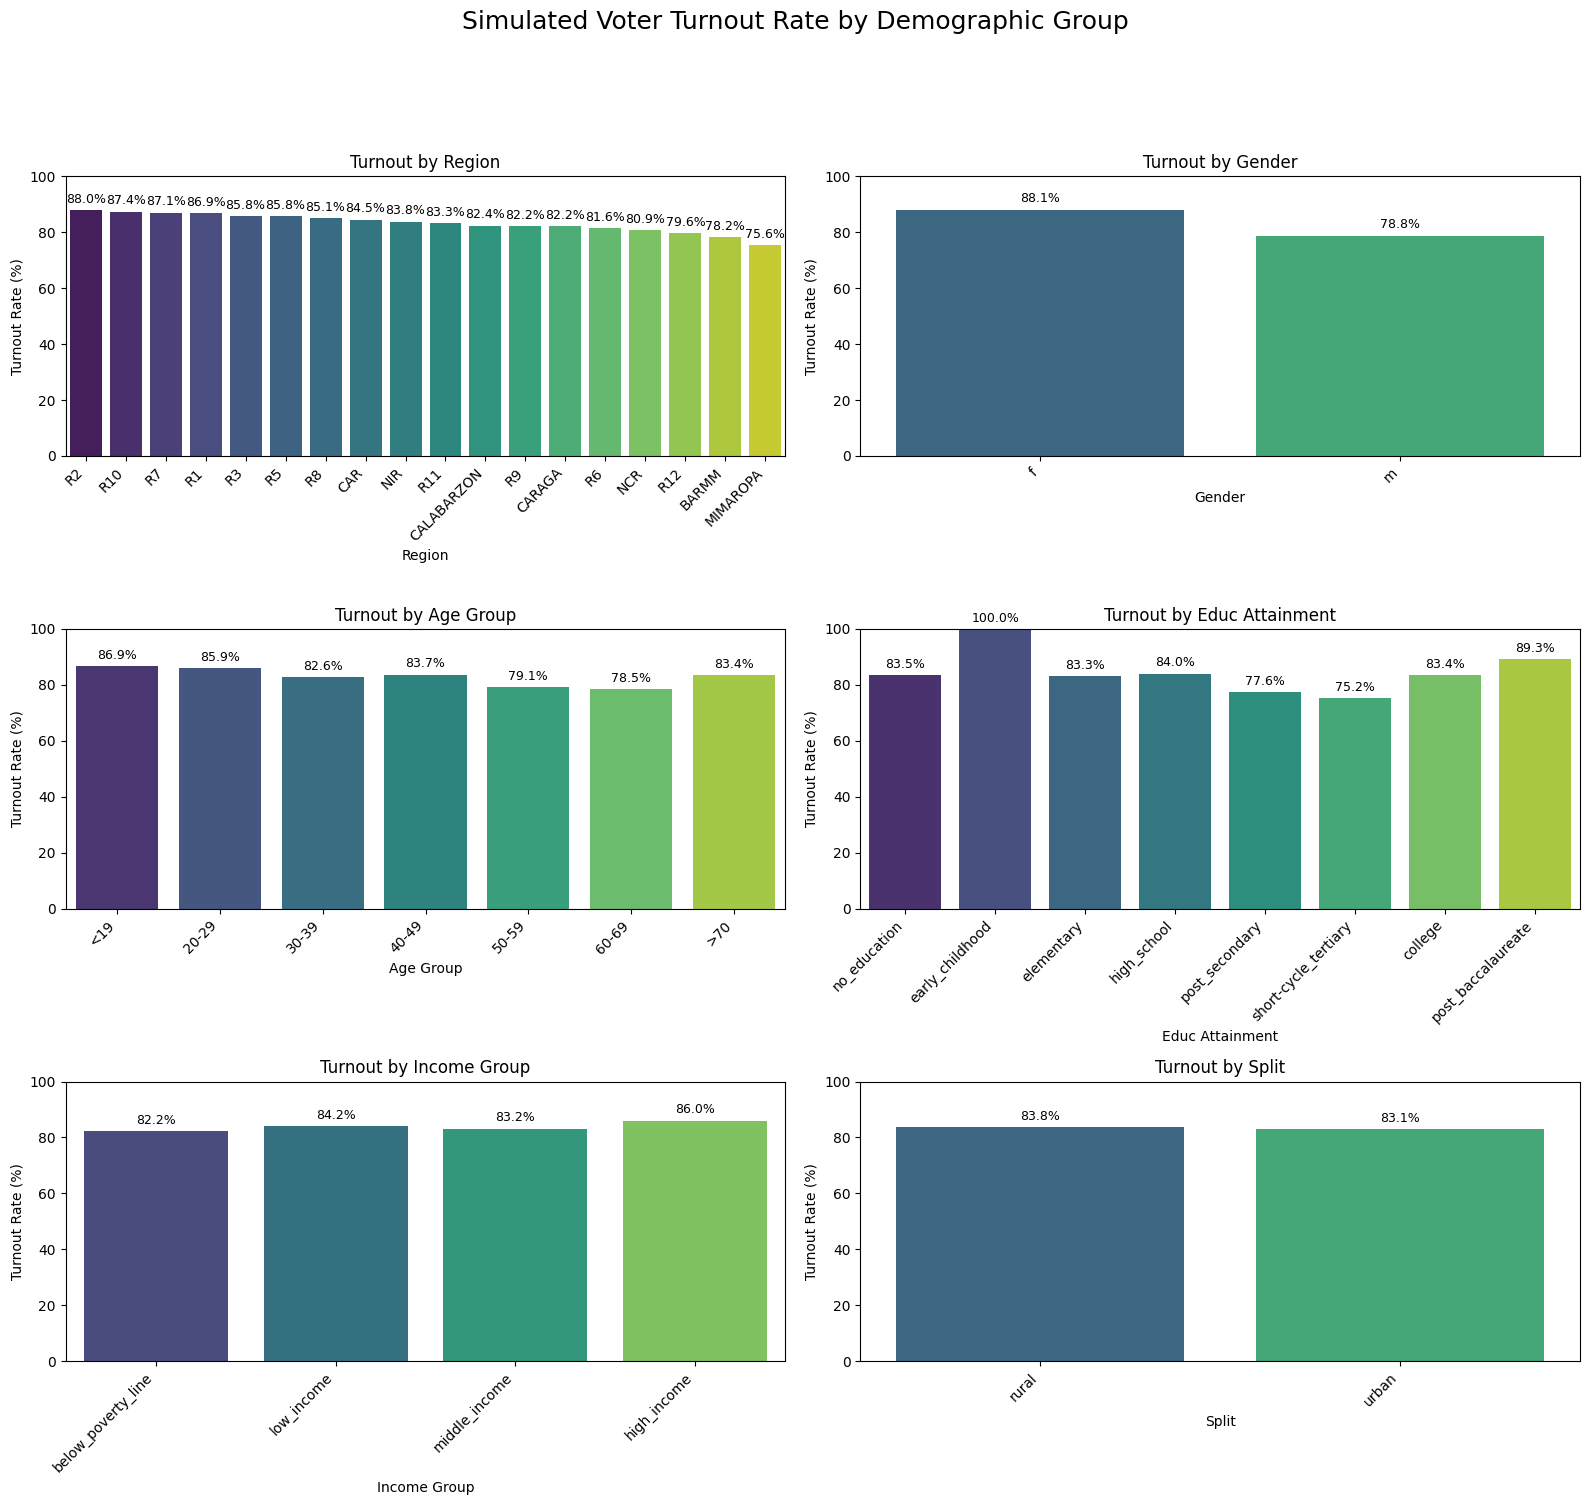

In [1102]:
plot_turnout_by_demographic(model)

# Visualization Functions

In [1103]:
def plot_demographic_distributions(model):
    # (Keep function as before)
    voters = [a for a in model.schedule.agents if isinstance(a, VoterAgent)];
    if not voters: print("No voter agents found."); return
    demo_data = [{'region': v.region, 'gender': v.gender, 'age_group': v.age_group, 'educ_attainment': v.educ_attainment, 'income_group': v.income_group, 'split': v.split} for v in voters]
    voter_df = pd.DataFrame(demo_data); demographic_columns = ['region', 'gender', 'age_group', 'educ_attainment', 'income_group', 'split']
    num_plots = len(demographic_columns); ncols = 2; nrows = (num_plots + 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(16, 6 * nrows)); axes = axes.flatten()
    fig.suptitle('Distribution of Voter Demographics in Simulation', fontsize=16, y=1.02)
    for i, col in enumerate(demographic_columns):
        ax = axes[i]; order = voter_df[col].value_counts().index
        sns.countplot(data=voter_df, y=col, ax=ax, order=order, palette='viridis'); ax.set_title(f'Distribution by {col.replace("_", " ").title()}'); ax.set_xlabel('Number of Voters'); ax.set_ylabel(col.replace("_", " ").title())
        for container in ax.containers: ax.bar_label(container, fmt='%d', label_type='edge', padding=3)
    for j in range(i + 1, len(axes)): fig.delaxes(axes[j])
    plt.tight_layout(rect=[0, 0.03, 1, 0.98]); plt.show()

def plot_issue_stance_distributions(model):
    # (Keep function as before)
    voters = [a for a in model.schedule.agents if isinstance(a, VoterAgent)];
    if not voters: print("No voter agents found."); return
    stance_data = [voter.issue_stances for voter in voters if hasattr(voter, 'issue_stances')]
    if not stance_data: print("No issue stance data collected."); return
    stance_df = pd.DataFrame(stance_data); issues = stance_df.columns; num_issues = len(issues)
    ncols = 2; nrows = (num_issues + 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(14, 4 * nrows)); axes = axes.flatten()
    fig.suptitle('Distribution of Voter Issue Stances', fontsize=16, y=1.01)
    for i, issue in enumerate(issues):
        ax = axes[i]; sns.histplot(data=stance_df, x=issue, ax=ax, kde=True, bins=20); ax.set_title(f'Stance on {issue.replace("_", " ").title()}'); ax.set_xlabel('Stance (User Defined 0-1 Scale)'); ax.set_ylabel('Number of Voters'); ax.set_xlim(0, 1)
    for j in range(i + 1, len(axes)): fig.delaxes(axes[j])
    plt.tight_layout(rect=[0, 0.03, 1, 0.99]); plt.show()

def plot_candidate_issue_stances(model):
    # (Keep function as before)
    candidates = [a for a in model.schedule.agents if isinstance(a, CandidateAgent)];
    if not candidates: print("No candidate agents found."); return
    stance_data = []
    for cand in candidates:
        if hasattr(cand, 'issue_stances'):
            stance_entry = cand.issue_stances.copy(); stance_entry['CandidateID'] = cand.unique_id; stance_entry['Type'] = getattr(cand, 'politician_type', 'Unknown')
            stance_data.append(stance_entry)
    if not stance_data: print("No issue stance data collected."); return
    stance_df = pd.DataFrame(stance_data); stance_df['Label'] = stance_df.apply(lambda row: f"{row['CandidateID']} ({row['Type']})", axis=1); stance_df = stance_df.set_index('Label')
    issue_columns = [col for col in stance_df.columns if col not in ['CandidateID', 'Type']]
    heatmap_data = stance_df[issue_columns].astype(float)
    plt.figure(figsize=(10, 8)); sns.heatmap(heatmap_data, annot=True, cmap="coolwarm", fmt=".2f", linewidths=.5, vmin=0, vmax=1); plt.title('Candidate Issue Stances (User Defined 0-1 Scale)'); plt.xlabel('Issue Area'); plt.ylabel('Candidate (Type)'); plt.xticks(rotation=45, ha='right'); plt.yticks(rotation=0); plt.tight_layout(); plt.show()

def plot_stances_by_demographic(model, demographic_column, plot_type='box'):
    # (Keep function as before)
    voters = [a for a in model.schedule.agents if isinstance(a, VoterAgent)];
    if not voters: print("No voter agents found."); return
    data_list = []
    for voter in voters:
        if hasattr(voter, 'issue_stances') and hasattr(voter, demographic_column):
            demo_value = getattr(voter, demographic_column)
            for issue, stance in voter.issue_stances.items(): data_list.append({'VoterID': voter.unique_id, demographic_column: demo_value, 'Issue': issue, 'Stance': stance})
    if not data_list: print(f"No stance or demographic data for '{demographic_column}'."); return
    stance_df = pd.DataFrame(data_list); categories = sorted(stance_df[demographic_column].unique())
    if demographic_column == 'age_group': age_order = ['<19', '20-29', '30-39', '40-49', '50-59', '60-69', '>70']; categories = [cat for cat in age_order if cat in categories]
    elif demographic_column == 'income_group': income_order = ['poverty', 'low', 'middle', 'high']; categories = [cat for cat in income_order if cat in categories]
    elif demographic_column == 'educ_attainment': edu_order = ['no_edu', 'early_child', 'elem', 'hs', 'post_sec', 'short_tert', 'college', 'post_bac']; categories = [cat for cat in edu_order if cat in categories]
    print(f"\nVisualizing Issue Stances by {demographic_column.replace('_', ' ').title()}...")
    plot_kind = plot_type if plot_type in ['box', 'violin'] else 'box'
    g = sns.catplot(data=stance_df, x=demographic_column, y='Stance', col='Issue', kind=plot_kind, col_wrap=3, sharey=True, height=4, aspect=1.2, order=categories, palette='viridis', legend=False)
    g.fig.suptitle(f'Voter Issue Stances by {demographic_column.replace("_", " ").title()}', y=1.03, fontsize=16)
    g.set_axis_labels(demographic_column.replace("_", " ").title(), "Stance (User Defined 0-1 Scale)"); g.set_titles("Issue: {col_name}"); g.set(ylim=(0, 1))
    for ax in g.axes.flatten(): ax.tick_params(axis='x', rotation=30); ax.grid(axis='y', linestyle='--', alpha=0.7)
    plt.show()

def analyze_decisive_factors(election, analysis_results):
    # (Keep function as before)
    candidates = election.get_candidates()
    if 'evaluations' not in analysis_results or analysis_results['evaluations'].empty: print("Evaluation data not available/empty."); return None
    eval_df = analysis_results['evaluations']; popularity = {c.name: getattr(c, 'popularity', 0.5) for c in candidates if hasattr(c, 'name')} # Use getattr
    mean_evals = eval_df.groupby('candidate_name')['evaluation_score'].mean().reset_index()
    plt.figure(figsize=(10, 6))
    for _, row in mean_evals.iterrows():
        cand_name = row['candidate_name']
        if cand_name in popularity:
            plt.scatter(popularity[cand_name], row['evaluation_score'], s=100, label=cand_name); plt.annotate(cand_name, (popularity[cand_name], row['evaluation_score']), textcoords="offset points", xytext=(0,10), ha='center')
    plt.xlabel('Candidate Popularity'); plt.ylabel('Mean Evaluation Score'); plt.title('Relationship Between Candidate Popularity and Voter Evaluation'); plt.grid(True, alpha=0.3); plt.savefig('popularity_vs_evaluation.png'); plt.show()
    return mean_evals

def plot_voter_evaluation_scores(model):
    # (Keep function as before)
    voters = [a for a in model.schedule.agents if isinstance(a, VoterAgent)]; candidates = [a for a in model.schedule.agents if isinstance(a, CandidateAgent)]
    if not voters or not candidates: print("No voters or candidates found."); return
    plot_data = []; first_choice_scores = defaultdict(list)
    for voter in voters:
        if not voter.ranked_vote: continue
        first_choice_candidate = voter.ranked_vote[0]
        for cand_id, score in voter.approval_scores.items():
            plot_data.append({'CandidateID': cand_id, 'EvaluationScore': score})
            if cand_id == first_choice_candidate.unique_id: first_choice_scores[cand_id].append(score)
    if not plot_data: print("No evaluation scores found."); return
    eval_df = pd.DataFrame(plot_data); avg_first_choice_scores = {cand_id: np.mean(scores) if scores else 0 for cand_id, scores in first_choice_scores.items()}
    avg_plot_data = []; candidate_order = sorted([c.unique_id for c in candidates])
    for cand_id in candidate_order:
         if cand_id in avg_first_choice_scores: avg_plot_data.append({'CandidateID': cand_id, 'AverageScore': avg_first_choice_scores[cand_id]})
    avg_df = pd.DataFrame(avg_plot_data)
    plt.figure(figsize=(14, 7)); sns.boxplot(data=eval_df, x='CandidateID', y='EvaluationScore', order=candidate_order, palette='viridis', showfliers=False)
    if not avg_df.empty: sns.stripplot(data=avg_df, x='CandidateID', y='AverageScore', order=candidate_order, marker='D', s=10, color='red', label='Avg Score from 1st Pref Voters', jitter=False)
    plt.title('Distribution of Voter Evaluation Scores per Candidate'); plt.xlabel('Candidate ID'); plt.ylabel('Issue-Based Evaluation Score (0-1)'); plt.ylim(-0.05, 1.05); plt.xticks(rotation=45, ha='right'); plt.grid(axis='y', linestyle='--', alpha=0.7); plt.legend(loc='best'); plt.tight_layout(); plt.show()

# --- NEW Visualization Function: Popularity Impact ---
def plot_popularity_impact_on_evaluation(model):
    """
    Visualizes how much candidate popularity influenced the final evaluation score
    relative to the voter's susceptibility to popularity.
    """
    voters = [a for a in model.schedule.agents if isinstance(a, VoterAgent)]
    candidates = [a for a in model.schedule.agents if isinstance(a, CandidateAgent)]
    if not voters or not candidates:
        print("No voters or candidates found.")
        return

    impact_data = []
    for voter in voters:
        if not hasattr(voter, 'popularity_influence'): continue # Skip if attribute missing

        for candidate in candidates:
            final_score = voter.evaluate_candidate(candidate)
            issue_score = voter.get_issue_score(candidate) # Use helper method
            popularity_impact = final_score - issue_score

            impact_data.append({
                'VoterID': voter.unique_id,
                'CandidateID': candidate.unique_id,
                'PopularityInfluence': voter.popularity_influence,
                'PopularityImpact': popularity_impact,
                'CandidatePopularity': getattr(candidate, 'popularity', 0.5) # For coloring
            })

    if not impact_data:
        print("Could not calculate popularity impact data.")
        return

    impact_df = pd.DataFrame(impact_data)

    # Create scatter plot with regression line
    plt.figure(figsize=(10, 6))
    sns.regplot(
        data=impact_df,
        x='PopularityInfluence',
        y='PopularityImpact',
        scatter_kws={'alpha': 0.2, 's': 10}, # Make points smaller and transparent
        line_kws={'color': 'red'}
    )

    plt.title('Impact of Popularity on Voter Evaluation Score')
    plt.xlabel('Voter Popularity Influence (Susceptibility)')
    plt.ylabel('Popularity Impact (Final Score - Issue Score)')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.axhline(0, color='grey', lw=1, linestyle=':') # Line at zero impact
    plt.tight_layout()
    plt.show()

    # Optional: Show impact colored by candidate popularity
    plt.figure(figsize=(10, 6))
    sns.scatterplot(
        data=impact_df,
        x='PopularityInfluence',
        y='PopularityImpact',
        hue='CandidatePopularity',
        palette='coolwarm',
        alpha=0.3,
        s=15
    )
    plt.title('Impact of Popularity on Voter Evaluation (Colored by Candidate Popularity)')
    plt.xlabel('Voter Popularity Influence (Susceptibility)')
    plt.ylabel('Popularity Impact (Final Score - Issue Score)')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.axhline(0, color='grey', lw=1, linestyle=':')
    plt.legend(title='Cand. Pop.')
    plt.tight_layout()
    plt.show()

def plot_dynasty_pref_vs_evaluation_binned(model, n_bins=10):
    """
    Visualizes the relationship between voter dynasty preference (binned)
    and the average final evaluation score given to dynastic vs non-dynastic candidates.

    Args:
        model: The Mesa ElectionModel instance after model.step() has been run.
        n_bins (int): The number of bins to group voter dynasty preference into.
    """
    voters = [a for a in model.schedule.agents if isinstance(a, VoterAgent)]
    candidates = [a for a in model.schedule.agents if isinstance(a, CandidateAgent)]
    if not voters or not candidates:
        print("No voters or candidates found.")
        return

    eval_data = []
    # Check if scores have been calculated
    if not any(hasattr(v, 'approval_scores') and v.approval_scores for v in voters):
         print("Warning: Voter approval scores not calculated yet. Run model.step() first.")
         # Attempt to run step if scores are missing
         try:
             print("Attempting to run model.step() to calculate scores...")
             model.step()
             # Re-check after running step
             if not any(hasattr(v, 'approval_scores') and v.approval_scores for v in voters):
                 print("Scores still missing after running step. Cannot generate plot.")
                 return
         except Exception as e:
             print(f"Error running model.step(): {e}. Cannot generate plot.")
             return


    for voter in voters:
        # Ensure voter has the necessary attributes
        if not hasattr(voter, 'dynasty_preference') or not hasattr(voter, 'approval_scores') or not voter.approval_scores:
             # print(f"Skipping voter {voter.unique_id} due to missing attributes or scores.") # Optional debug print
             continue

        for cand in candidates:
            cand_id = cand.unique_id
            # Check if score exists for this candidate (it should if step ran)
            if cand_id not in voter.approval_scores:
                # print(f"Score for candidate {cand_id} not found for voter {voter.unique_id}") # Optional debug print
                continue

            score = voter.approval_scores[cand_id]
            is_dynasty = getattr(cand, 'is_dynasty', False) # Default to False if attribute missing

            eval_data.append({
                'VoterID': voter.unique_id,
                'CandidateID': cand_id,
                'DynastyPreference': voter.dynasty_preference, # Voter's preference (-1 to 1)
                'FinalEvaluationScore': score, # The final combined score
                'IsDynasty': is_dynasty
            })

    if not eval_data:
        print("Could not gather evaluation data for dynasty plot.")
        return

    eval_df = pd.DataFrame(eval_data)

    # --- Binning and Aggregation ---
    # Create bins for dynasty preference
    bins = np.linspace(-1, 1, n_bins + 1)
    labels = [(bins[i] + bins[i+1]) / 2 for i in range(n_bins)] # Use bin centers as labels

    eval_df['PreferenceBin'] = pd.cut(eval_df['DynastyPreference'], bins=bins, labels=labels, include_lowest=True)

    # Calculate mean and standard error per bin and dynasty status
    agg_data = eval_df.groupby(['PreferenceBin', 'IsDynasty'], observed=False)['FinalEvaluationScore'].agg(['mean', 'sem']).reset_index() # sem = standard error of the mean

    # --- Plotting ---
    print("\nPlotting Binned Voter Dynasty Preference vs Average Evaluation Score...")
    plt.figure(figsize=(10, 6))

    # Plot Dynastic Candidates
    dynasty_true = agg_data[agg_data['IsDynasty'] == True]
    plt.errorbar(dynasty_true['PreferenceBin'], dynasty_true['mean'], yerr=dynasty_true['sem'],
                 fmt='-o', capsize=5, label='Dynastic Candidate', color='orange', alpha=0.8)

    # Plot Non-Dynastic Candidates
    dynasty_false = agg_data[agg_data['IsDynasty'] == False]
    plt.errorbar(dynasty_false['PreferenceBin'], dynasty_false['mean'], yerr=dynasty_false['sem'],
                 fmt='-s', capsize=5, label='Non-Dynastic Candidate', color='grey', alpha=0.8)


    plt.title('Voter Dynasty Preference vs. Average Candidate Evaluation Score (Binned)')
    plt.xlabel('Voter Dynasty Preference Bin Center (-1=Anti, +1=Pro)')
    plt.ylabel('Average Final Evaluation Score (0-1)')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.ylim(-0.05, 1.05)
    plt.xlim(-1.05, 1.05)
    plt.legend(title='Candidate Type', loc='best')
    plt.tight_layout()
    plt.show()

def plot_turnout_by_demographic(model):
    """
    Calculates and plots the voter turnout percentage for various demographic groups
    based on the simulation results.

    Args:
        model: The Mesa ElectionModel instance after model.step() has been run.
               Requires VoterAgents to have demographic attributes and the 'will_vote' attribute.
    """
    voters = [a for a in model.schedule.agents if isinstance(a, VoterAgent)]
    if not voters:
        print("No voter agents found in the model.")
        return

    # Check if the turnout simulation has likely run (i.e., will_vote exists)
    # Check the first voter, assuming all voters will have the attribute if one does after step()
    if not hasattr(voters[0], 'will_vote'):
        print("Warning: Voter agents do not have the 'will_vote' attribute.")
        print("Please ensure model.step() has been run before calling this function.")
        # Optionally, you could try running model.step() here if appropriate for your workflow
        # try:
        #     print("Attempting to run model.step()...")
        #     model.step()
        #     if not hasattr(voters[0], 'will_vote'): # Re-check
        #        print("Attribute 'will_vote' still missing after step(). Cannot plot.")
        #        return
        # except Exception as e:
        #     print(f"Error running model.step(): {e}. Cannot plot.")
        #     return
        return # Return if attribute is missing


    # --- Collect Data ---
    demographic_data = []
    demographic_columns = ['region', 'gender', 'age_group', 'educ_attainment', 'income_group', 'split']

    for voter in voters:
        # Initialize data_entry for each voter
        data_entry = {'will_vote': getattr(voter, 'will_vote', False)} # Default to False if missing
        valid_entry = True
        for col in demographic_columns:
            if hasattr(voter, col):
                data_entry[col] = getattr(voter, col)
            else:
                # Print warning only once per missing attribute type for brevity
                if not hasattr(plot_turnout_by_demographic, f"warned_{col}"):
                     print(f"Warning: At least one voter missing demographic attribute '{col}'. Voters without it will be skipped for this plot.")
                     setattr(plot_turnout_by_demographic, f"warned_{col}", True)
                valid_entry = False
                break # Skip this voter if any demographic is missing
        if valid_entry:
            # Ensure all expected keys are present before appending
            if all(key in data_entry for key in demographic_columns + ['will_vote']):
                 demographic_data.append(data_entry)

    # Reset warnings for next call
    for col in demographic_columns:
         if hasattr(plot_turnout_by_demographic, f"warned_{col}"):
             delattr(plot_turnout_by_demographic, f"warned_{col}")


    if not demographic_data:
        print("No valid voter data with demographics and turnout status found.")
        return

    voter_df = pd.DataFrame(demographic_data)
    # Convert will_vote to integer (1 for True, 0 for False) for mean calculation
    voter_df['will_vote'] = voter_df['will_vote'].astype(int)


    # --- Plotting ---
    print("\nPlotting Simulated Voter Turnout Rate by Demographic Group...")

    num_plots = len(demographic_columns)
    ncols = 2
    nrows = (num_plots + ncols - 1) // ncols # Calculate necessary rows

    fig, axes = plt.subplots(nrows, ncols, figsize=(16, 5 * nrows))
    axes = axes.flatten() # Flatten the axes array for easy iteration

    fig.suptitle('Simulated Voter Turnout Rate by Demographic Group', fontsize=18, y=1.03)

    for i, col in enumerate(demographic_columns):
        ax = axes[i]

        # Calculate turnout percentage for each category in the demographic column
        # Check if column exists and has data before grouping
        if col not in voter_df.columns or voter_df[col].isnull().all():
             print(f"Skipping plot for '{col}' due to missing data.")
             ax.set_title(f'Turnout by {col.replace("_", " ").title()} (No Data)')
             ax.text(0.5, 0.5, 'No Data Available', horizontalalignment='center', verticalalignment='center', transform=ax.transAxes)
             continue # Skip to the next plot if no data for this column

        # Ensure the grouping column is treated as categorical for correct grouping
        voter_df[col] = voter_df[col].astype('category')

        turnout_rates = voter_df.groupby(col, observed=False)['will_vote'].mean() * 100 # Use observed=False
        turnout_rates = turnout_rates.sort_values(ascending=False) # Sort for better visualization

        # Define order for specific categorical plots if needed
        order = turnout_rates.index
        # Define known order for specific demographics
        if col == 'age_group':
            age_order = ['<19', '20-29', '30-39', '40-49', '50-59', '60-69', '>70']
            order = pd.Categorical(voter_df[col].unique(), categories=age_order, ordered=True)
            order = order.dropna().sort_values() # Use only categories present in the data, sorted correctly
            # Recalculate turnout rates with the correct order if needed (or pass order to sns.barplot)
            turnout_rates = turnout_rates.reindex(order).dropna()

        elif col == 'income_group':
            income_order = ['below_poverty_line', 'low_income', 'middle_income', 'high_income']
            order = pd.Categorical(voter_df[col].unique(), categories=income_order, ordered=True)
            order = order.dropna().sort_values()
            turnout_rates = turnout_rates.reindex(order).dropna()

        elif col == 'educ_attainment':
            edu_order = ['no_education', 'early_childhood', 'elementary', 'high_school', 'post_secondary', 'short-cycle_tertiary', 'college', 'post_baccalaureate']
            order = pd.Categorical(voter_df[col].unique(), categories=edu_order, ordered=True)
            order = order.dropna().sort_values()
            turnout_rates = turnout_rates.reindex(order).dropna()
        else:
             # For others like region, gender, split, sorted by rate is fine
             order = turnout_rates.index


        # Check if there are any rates to plot after potential filtering/reindexing
        if turnout_rates.empty:
             print(f"Skipping plot for '{col}' as no turnout rates could be calculated.")
             ax.set_title(f'Turnout by {col.replace("_", " ").title()} (No Rates)')
             ax.text(0.5, 0.5, 'No Rates Calculated', horizontalalignment='center', verticalalignment='center', transform=ax.transAxes)
             continue


        # Create the bar plot
        sns.barplot(x=turnout_rates.index, y=turnout_rates.values, ax=ax, order=order, palette='viridis')

        # Add percentage labels to the bars
        for container in ax.containers:
            ax.bar_label(container, fmt='%.1f%%', label_type='edge', padding=3, fontsize=9)

        # Set titles and labels
        ax.set_title(f'Turnout by {col.replace("_", " ").title()}')
        ax.set_xlabel(col.replace("_", " ").title())
        ax.set_ylabel('Turnout Rate (%)')
        ax.set_ylim(0, 100) # Y-axis from 0% to 100%

        # --- CORRECTED LINE ---
        # Set rotation and alignment for x-tick labels using plt.setp
        plt.setp(ax.get_xticklabels(), rotation=45, ha='right')

    # Hide any unused subplots
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout(rect=[0, 0.03, 1, 0.97]) # Adjust layout to prevent title overlap
    plt.show()